In this notebook, we'll explore the essential concepts of data loading in PyTorch.  Efficient data handling is crucial for training deep learning models, especially when working with large datasets. PyTorch's **DataLoader** facilitates this by enabling easy loading, batching, shuffling, and parallel processing of data.

# Import Dependencies

In [1]:
import os
import PIL
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


import torch
import torchvision

import warnings
warnings.filterwarnings("ignore")

# Visualization Utility

In [2]:
!pip install torchshow -q

In [3]:
import torchshow as ts

In [4]:
def visualize_samples(images, labels, class_names = None,num_samples = 5):

    plt.figure(figsize = (10,5))

    for i in range(num_samples):

        plt.subplot(1,num_samples, i+1)

        image = (images[i] * (0.5)) + (0.5) #denormalize
        label = labels[i].item()

        plt.imshow(image.permute(1,2,0) )
        title = f"Label: {label}"

        if class_names:
           title = f"Label: {class_names[label]}"

        plt.title(title)
        plt.axis('off')
    plt.show()


# Using Torchvision Datasets

PyTorch’s `torchvision.datasets` offers ready-to-use datasets like MNIST, CIFAR-10, and ImageNet. These are pre-packaged with standard training and test splits, and often come with labels, making them ideal for quick experiments.

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


common_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize the images to have mean 0.5 and std 0.5
])

mnist_train_set = datasets.CIFAR10(root=".", download = True, train = True, transform = common_transform)
mnist_val_set = datasets.CIFAR10(root=".", download = True, train = False, transform = common_transform)

mnist_train_loader = DataLoader(mnist_train_set, batch_size = 16, shuffle = True)
mnist_val_loader = DataLoader(mnist_val_set, batch_size = 16, shuffle = False)

print(len(mnist_train_set))

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


50000


In [6]:
cifar10_classes = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}


#sanity check
len(next(iter(mnist_train_loader)))

2

Images shape: torch.Size([16, 3, 32, 32]) ; Labels shape: torch.Size([16])


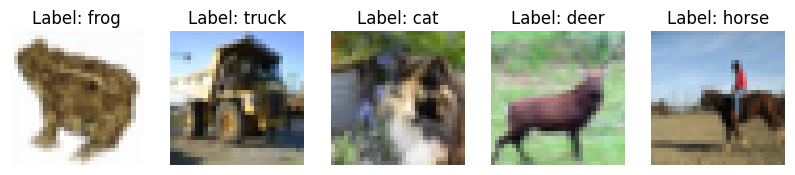

In [7]:
for images, labels in mnist_train_loader:
    print(f"Images shape: {images.shape} ; Labels shape: {labels.shape}")
    #ts.show(images)
    visualize_samples(images, labels, cifar10_classes)
    break

**Part 1 Summary**

In this section, we used torchvision.datasets to download the CIFAR-10 dataset. We created a transformation pipeline to convert the PIL images into PyTorch tensors and normalize them. Finally, we wrapped the datasets in DataLoaders (shuffling the training set but not the validation set) to efficiently pass the data in batches of 16, and visualized a single batch with its class labels.

# Using ImageFolder

 For datasets organized into directories by class, the `datasets.ImageFolder` class provides a straightforward way to load images.



In [8]:
!wget -q "https://www.dropbox.com/s/45jdd8padeyjq6t/10_Monkey_Species.zip?dl=1" -O "10_Monkey_Species.zip"

!unzip -q "10_Monkey_Species.zip"

In [9]:
root = os.getcwd()

common_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.ToTensor(),  # Convert PIL images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize the images to have mean 0.5 and std 0.5
])

train_root = os.path.join("10_Monkey_Species", "training", "training")
val_root = os.path.join(root, "10_Monkey_Species", "validation", "validation")

In [10]:
train_dataset = datasets.ImageFolder(root = train_root, transform = common_transform)
val_dataset = datasets.ImageFolder(root = val_root, transform = common_transform)

train_loader  = DataLoader(train_dataset, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = True)

print("Len of Train Dataset", len(train_dataset))
print("Len of Val Dataset", len(val_dataset))

Len of Train Dataset 1097
Len of Val Dataset 272


In [11]:
#sanity check
len(next(iter(train_loader)))

2

Images shape: torch.Size([16, 3, 48, 48]) ; Labels shape: torch.Size([16])


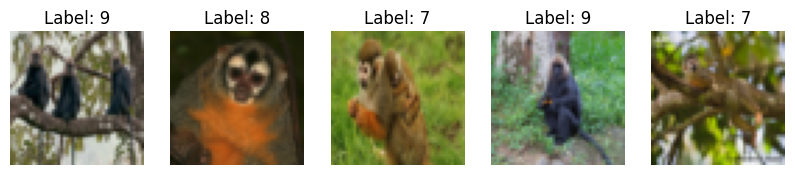

In [12]:
for images, labels in train_loader:
    print(f"Images shape: {images.shape} ; Labels shape: {labels.shape}")
    # ts.show(images)
    visualize_samples(images, labels)
    break

**Part 2 Summary**

In this section, we used datasets.ImageFolder to easily load a dataset that was already organized into subdirectories by class. Because the raw images might be different sizes, we added a transforms.Resize((48, 48)) step to our pipeline to make them uniform before converting them to tensors. We then created our training and validation DataLoaders (shuffling both) and visualized a batch with their label indices.

# Creating Custom DataLoader

 When working with datasets that don’t fit the standard formats, we can subclass `torch.utils.data.Dataset` to create a custom dataset. This method offers flexibility, allowing us to define how data is loaded, transformed, and accessed.

In [13]:
from torch.utils.data import Dataset

os.makedirs("FER2013", exist_ok=True)

In [14]:
!wget -q "https://www.dropbox.com/scl/fi/6171214eg2qmrahw1ijvw/FER2013.zip?rlkey=hjd7kj1vt015r0yusfuihbfa6&st=y8bur912&dl=1" -O FER2013.zip

!unzip -q -o FER2013.zip

In [15]:
!sudo apt-get install tree -y > /dev/null 2>&1

In [16]:
!tree "./fer2013"

./fer2013
├── fer2013.bib
├── fer2013.csv
├── README
├── test.csv
└── train.csv

0 directories, 5 files


In [17]:
# Load the dataset
csv_file = 'fer2013/train.csv'
df = pd.read_csv(csv_file)

# Split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Print the sizes of the datasets
print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")

Train size: 22967, Validation size: 5742


In [18]:
class FER2013Dataset(Dataset):
    def __init__(self, data_frame, transform=None):
        self.data_frame = data_frame
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        # 1. Get the row
        sample = self.data_frame.iloc[idx]

        # 2. Parse pixels: convert space-separated string to 48x48 numpy array
        image = np.array(sample['pixels'].split(), dtype=np.uint8).reshape(48, 48)

        # 3. Get label
        label = int(sample['emotion'])

        # 4. Convert to PIL RGB (Required for torchvision transforms)
        image = PIL.Image.fromarray(image).convert('RGB')

        # 5. Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

In [19]:
# Create datasets
train_dataset = FER2013Dataset(data_frame=train_df, transform=common_transform)
val_dataset = FER2013Dataset(data_frame=val_df, transform=common_transform)

train_loader  = DataLoader(train_dataset, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = True)

print("Number of Samples in Train Dataset:", len(train_dataset))
print("Number of Samples in Validation Dataset:", len(val_dataset))

Number of Samples in Train Dataset: 22967
Number of Samples in Validation Dataset: 5742


In [20]:
#sanity check
len(next(iter(train_loader)))

2

In [21]:
class_mapping = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

Images shape: torch.Size([16, 3, 48, 48]) ; Labels shape: torch.Size([16])


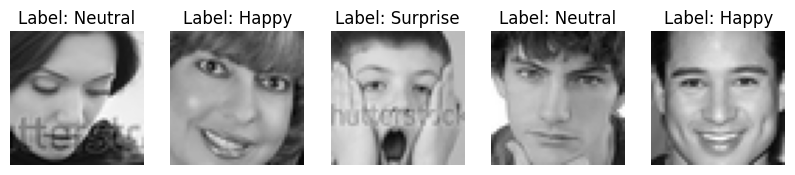

In [22]:
for images, labels in train_loader:
    print(f"Images shape: {images.shape} ; Labels shape: {labels.shape}")
    # ts.show(images)
    visualize_samples(images, labels, class_mapping)
    break

**Part 3 Summary**

In this section, I created a custom FER2013Dataset class by subclassing torch.utils.data.Dataset. Since the data was provided in a CSV format with pixel values as strings, I implemented a custom getitem method to reshape those strings into 48x48 images and convert them to PIL format for processing. I then split the data using a 20% validation split and successfully visualized the facial expressions with their corresponding emotion labels.

In [23]:
print("Student Name: GIDEON APPIAH")
print("Student ID:   G00457858")
print("Lab:          04 — Dataloaders_in_PyTorch_Classification")

Student Name: GIDEON APPIAH
Student ID:   G00457858
Lab:          04 — Dataloaders_in_PyTorch_Classification
